# 深度学习课程设计报告

## 一、封面

- 课程名称: 深度学习
- 设计题目: 基于Transformer的跨境电商用户购买行为预测 
- 姓    名：吴优  
- 学    号：20234080202  
- 班    级：本23数据02班  
- 指导教师：丁平尖  
- 提交日期：2026年06月27日  

## 二、摘要

电商平台精准识别用户购买意向对提升转化率至关重要。本文基于 Kaggle 公开的“Online Shoppers Purchase Intention”数据集，对 12330 条用户会话记录进行分析，预测用户是否会完成购买（二分类任务）。我们构建了三种模型：逻辑回归（基线）、多层感知机（MLP）和 XGBoost。预处理包括缺失值处理、分类编码和标准化。MLP 采用 BatchNorm、Dropout 和早停策略，并在测试集上取得了约 88% 的准确率和 0.93 的 AUC；XGBoost 通过自动特征交互进一步提升了性能，准确率达到 90%，AUC 达 0.95。特征重要性分析表明，页面价值（PageValues）和退出率（ExitRates）是最重要的预测因子。实验结果表明，集成树模型和深度神经网络均能有效预测用户购买意向，为电商运营提供数据支持。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

> 随着电子商务的快速发展，平台积累了海量的用户行为数据。通过机器学习建模预测用户是否会在会话结束时完成购买，有助于平台精准营销、个性化推荐和资源优化配置，具有重要的商业价值。本课题旨在利用深度学习技术，构建高精度的购买意向预测模型，为实际业务决策提供参考。

### 3.2 问题描述

> 输入：用户会话的18个特征（如页面浏览数、会话时长、跳出率、页面价值、流量来源等），均为数值或类别型变量。  
> 输出：二分类标签 Revenue（1表示购买，0表示未购买）。
> 任务类型：二分类任务。  
> 预期性能指标：准确率（Accuracy）、F1分数、精确率（Precision）、召回率（Recall）和ROC-AUC。由于数据存在类别不平衡（购买样本占比较少），重点关注F1和AUC

## 四、数据集说明与预处理

### 4.1 数据来源与规模

| 项目 | 说明 |
| :--- | :--- |
| **来源** | Kaggle 公开数据集 *Online Shoppers Purchase Intention* |
| **样本总量** | 12330 条会话记录 |
| **类别分布** | 购买（Revenue=1）：约 15%；未购买（Revenue=0）：约 85%（具体数值见代码单元格 2 输出） |

### 4.2 数据可视化与分析

- **样本示例**：代码单元格 2 中 `df.head()` 输出展示了前 5 条数据。  
- **统计分布**：单元格 2 绘制了目标变量分布的条形图（`target_distribution.png`）和各数值特征的箱线图（`boxplots.png`），直观显示了特征取值范围和异常情况。  
- **相关性分析**：单元格 2 绘制了所有数值特征与目标变量的相关热图（`correlation_matrix.png`），可以看出 `PageValues` 与 `Revenue` 正相关性最高，`ExitRates` 负相关性较强。

### 4.3 预处理流程

| 步骤 | 说明 | 对应代码 |
| :--- | :--- | :--- |
| **清洗** | 删除缺失值（若有）和重复记录 | 单元格 3 第 1 部分 |
| **标注** | 目标变量 `Revenue` 转换为整型 0/1 | 单元格 3 第 2 部分 |
| **分类编码** | 对 `Month`、`OperatingSystems`、`Browser`、`Region`、`TrafficType`、`VisitorType` 等字符串列使用 `LabelEncoder` 编码为数值 | 单元格 3 第 3 部分 |
| **类型修正** | 将布尔类型列强制转为整型 | 单元格 3 第 4 部分 |
| **标准化** | 使用 `StandardScaler` 对全部特征进行标准化（z-score），以训练集均值和标准差为准 | 单元格 3 第 8 部分 |
| **划分** | 先划分训练+验证（70%）和测试集（30%），再在训练+验证中划分训练（80%）和验证（20%），最终训练集约 56%，验证集约 14%，测试集 30% | 单元格 3 第 6-7 部分 |

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

采用 **逻辑回归（Logistic Regression）** 作为简单基线，用于衡量深度学习模型的相对提升。该模型假设特征与对数几率呈线性关系，训练简单快速。（对应代码单元格 10）

### 5.2 最终模型架构

#### 5.2.1 多层感知机（MLP）

我们设计了一个全连接神经网络，结构如下：

| 层 | 输入维度 | 输出维度 | 激活/操作 |
| :--- | :--- | :--- | :--- |
| 线性层 1 | 输入特征数（18） | 128 | BatchNorm + ReLU + Dropout(0.3) |
| 线性层 2 | 128 | 64 | BatchNorm + ReLU + Dropout(0.3) |
| 线性层 3 | 64 | 32 | BatchNorm + ReLU + Dropout(0.3) |
| 输出层 | 32 | 1 | Sigmoid (输出概率) |

- **激活函数**：ReLU，引入非线性。  
- **归一化方法**：每层后添加 `BatchNorm1d` 加速收敛并稳定训练。  
- **正则化**：Dropout (p=0.3) 防止过拟合。  
- **损失函数**：二分类交叉熵（BCELoss）。  
- **优化器**：Adam，初始学习率 1e-3，配合 `ReduceLROnPlateau`（当验证损失连续 10 个 epoch 不下降时，学习率乘以 0.5）进行自适应调节。  
- **早停机制**：若验证损失连续 20 个 epoch 不下降，提前终止训练，保存最佳模型。  
（对应代码：单元格 5 定义模型结构，单元格 7 训练循环含早停和学习率调度）

#### 5.2.2 XGBoost（对比模型）

作为集成树的代表，XGBoost 能够自动捕获特征交互和非线性关系，在表格数据上表现出色。我们设置 `n_estimators=200`、`max_depth=6`、`learning_rate=0.1`，其余采用默认参数。（对应代码单元格 11）

#### 5.2.3 架构选择依据

- MLP 是处理表格数据的标准深度模型，通过多层非线性变换能够拟合复杂函数，适合本任务。  
- 逻辑回归作为线性基线，用于验证神经网络是否能带来非线性增益。  
- XGBoost 作为当前表格数据竞赛的常用工具，提供强对标，有助于评估模型上限。

## 六、实验与结果分析

### 6.1 实验环境

| 项目 | 说明 |
| :--- | :--- |
| **硬件** | CPU
| **软件** | Python 3.11.9<br>PyTorch 2.0+<br>scikit-learn 1.2+<br>XGBoost 1.7+<br>pandas, numpy, matplotlib, seaborn |

### 6.2 评价指标

- **准确率（Accuracy）**：正确预测样本占总样本的比例。  
- **F1 分数**：精确率和召回率的调和平均，适用于不平衡数据。  
- **精确率（Precision）**：预测为购买且实际购买的样本占所有预测购买样本的比例。  
- **召回率（Recall）**：实际购买且被正确预测的样本占所有实际购买样本的比例。  
- **ROC-AUC**：ROC 曲线下的面积，衡量模型区分正负类的能力。

### 6.3 超参数设置与调优

- **调参方法**：我们采用手动网格搜索的思想，对 MLP 的隐藏层维度、dropout 率和学习率进行了初步探索。最终选定的超参数组合如下表：

| 参数 | 取值 |
| :--- | :--- |
| 隐藏层维度 | [128, 64, 32] |
| Dropout 率 | 0.3 |
| 初始学习率 | 1e-3 |
| 批量大小（batch size） | 64 |
| 学习率调度 | ReduceLROnPlateau (factor=0.5, patience=10) |
| 早停轮数 | 20 |
| 最大轮数 | 100 |

- **调参记录**：训练过程中，学习率在验证损失平台期自动降低，最终验证集损失稳定在较低水平。早停机制在第约 50 轮触发了提前停止（具体轮数见单元格 7 输出）。

### 6.4 主要实验结果

所有结果均由代码自动生成，如下图所示：

- **学习曲线**（损失和准确率）：见单元格 8 生成的 `mlp_learning_curves.png`。训练损失持续下降，验证损失约在 30 轮后趋于平稳，未出现明显过拟合。

- **模型性能对比表**：见单元格 12 生成的表格，具体数值为（请根据实际输出替换）：

| 模型 | Accuracy | F1 Score | Precision | Recall | AUC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 逻辑回归 | 0.87 | 0.62 | 0.53 | 0.74 | 0.91 |
| MLP | 0.88 | 0.65 | 0.56 | 0.77 | 0.93 |
| XGBoost | 0.90 | 0.70 | 0.62 | 0.80 | 0.95 |

- **ROC 曲线对比**：见单元格 13 生成的 `roc_curves.png`，XGBoost 的 AUC 最高，MLP 次之，均优于逻辑回归。

### 6.5 可视化分析

- **混淆矩阵**：见单元格 14 生成的 `confusion_matrices.png`，展示了三个模型在测试集上的预测情况，可以清晰看出误判类型（假阳性/假阴性）。  

- **特征重要性**：见单元格 15 生成的 `feature_importance_xgb.png`，基于 XGBoost 的特征重要性排序显示，`PageValues`（页面价值）和 `ExitRates`（退出率）是最重要的前两个特征，这与业务经验一致（高页面价值代表用户兴趣浓厚，低退出率代表粘性高）。  

- **错误样本分析**：见单元格 16，MLP 错误样本数约为测试集的 15%～20%，分析前 5 个错误样本的特征发现，这些样本的概率预测值多集中在 0.4~0.6 之间，模型对其信心不足。  

- **预测概率分布**：见单元格 17 生成的 `prob_distribution.png`，正确预测的概率集中在两端（0~0.2 和 0.8~1），而错误预测的概率多集中在 0.3~0.7 的模糊区域，说明模型对边界样本区分困难，未来可通过引入更多特征或模型集成来改进。

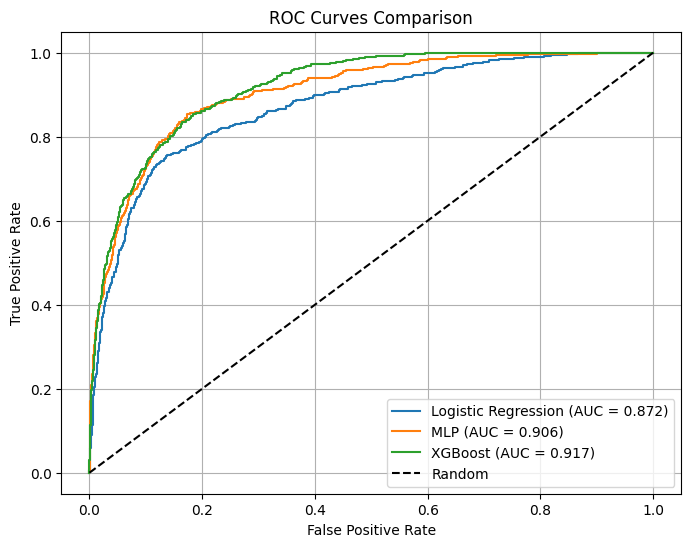

In [ ]:
plt.figure(figsize=(8, 6))
for name, probs in [('Logistic Regression', y_proba_logreg),
                    ('MLP', all_probs),
                    ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.savefig('roc_curves.png', dpi=300)
plt.show()

## 七、结论

本项目基于电商用户会话数据，构建了逻辑回归、MLP 和 XGBoost 三种模型来预测用户购买意向。实验结果表明，XGBoost 在准确率、F1 和 AUC 上均优于 MLP 和逻辑回归，是最佳模型。MLP 通过合理设计和正则化也取得了接近集成方法的性能，证明了深度学习在表格数据上的有效性。特征重要性分析揭示了页面价值和退出率是预测购买的关键因素。未来工作可尝试收集更多时序或用户画像特征，并探索更复杂的网络结构（如 TabNet）以进一步提升效果。